# Recuit Simulé — VRPTW Multi-Véhicules

---

## Contexte

Dans le cadre du projet ADEME sur la **mobilité multimodale intelligente**, nous cherchons à optimiser les tournées de livraison. Le problème est modélisé comme un **VRPTW** (Vehicle Routing Problem with Time Windows) :

- Plusieurs véhicules partent d'un dépôt commun
- Chaque client doit être visité **exactement une fois**
- Chaque client a une **fenêtre temporelle** : il ne peut être livré qu'entre `[a, b]`
- Chaque véhicule a une **capacité maximale** de marchandises
- L'objectif : **minimiser la distance totale** parcourue par tous les véhicules

Ce problème est **NP-difficile** : il est impossible de tester toutes les solutions possibles dès que n dépasse une dizaine de clients. Il faut donc des algorithmes intelligents.

Dans ce notebook, nous présentons notre deuxième méthode de résolution : le **Recuit Simulé**, une métaheuristique inspirée de la physique.

---

## 1. Qu'est-ce que le Recuit Simulé ?

### L'intuition

Le recuit simulé s'inspire de la **métallurgie** : quand un forgeron chauffe du métal puis le refroidit lentement, les atomes bougent beaucoup au début et se stabilisent progressivement dans une configuration optimale.

En optimisation, on traduit cette idée ainsi :

```
Métal chaud   →  beaucoup de mouvement  →  exploration large des solutions
Métal froid   →  peu de mouvement       →  stabilisation sur la meilleure solution trouvée
```

### Le problème de l'optimum local

Un algorithme qui descend toujours vers la meilleure solution immédiate se retrouve coincé dans un **optimum local** — une bonne solution, mais pas la meilleure possible :

```
coût
 ↑
 │     /\        /\
 │    /  \      /  \
 │   /    \    /    \
 │  /  X   \  /      \____
 │ /        \/            \
 └──────────────────────────→ solutions
        ↑                 ↑
   optimum local     optimum global
   (on est coincé)   (ce qu'on cherche)
```

Le recuit résout ce problème en acceptant **parfois des solutions moins bonnes** pour traverser les collines et explorer plus loin.

### L'algorithme

```
1. Partir d'une solution initiale S
2. Répéter N fois :
   a. Générer un voisin S' (petite modification de S)
   b. Calculer delta = coût(S') - coût(S)
   c. Si delta < 0  → accepter S' (c'est mieux)
      Si delta ≥ 0  → accepter S' avec probabilité  p = e^(-delta/T)
   d. Refroidir : T = T × alpha
3. Retourner la meilleure solution vue
```

---

## 2. La Température — le paramètre clé

La température `T` est un **compteur qui descend mécaniquement** à chaque itération, peu importe ce qui se passe :

```
Début  : T = 5000
Iter 1 : T = 5000 × 0.998 = 995.0
Iter 2 : T = 995  × 0.998 = 990.0
...
Iter 1000 : T ≈ 67
Iter 5000 : T ≈ 0.000002
```

Elle n'a **rien à voir avec le coût** — c'est un minuteur qui contrôle à quel point on est permissif.

Son seul rôle : apparaître dans la formule de probabilité d'acceptation :

$$p = e^{-\Delta C / T}$$

| Température | delta (dégradation) | Probabilité d'accepter |
|---|---|---|
| T = 1000 (début) | +50 | e^(-50/1000) = **95%** |
| T = 100 (milieu) | +50 | e^(-50/100) = **61%** |
| T = 10 (fin)     | +50 | e^(-50/10)  = **0.7%** |

**Au début**, T est grande : on accepte presque tout → on explore largement.  
**À la fin**, T est petite : on n'accepte presque rien → on affine la meilleure solution trouvée.

---

## 3. Les Mouvements de Voisinage

À chaque itération, on doit **modifier légèrement la solution courante** pour obtenir un voisin. Nous utilisons deux types de mouvements :

### Mouvement 1 — 2-opt intra-route

On inverse un segment dans la route d'un véhicule. Cela supprime les croisements inutiles sur la carte :

```
Avant : dépôt → A → B → C → D → dépôt
                    ↕ on inverse ce segment
Après : dépôt → A → C → B → D → dépôt
```

### Mouvement 2 — Or-opt (déplacement inter-routes)

On prend un client dans un véhicule et on le déplace dans un autre. Cela rééquilibre la charge entre les véhicules :

```
Avant :
  Véhicule 1 : dépôt → A → [B] → C → dépôt
  Véhicule 2 : dépôt → D → E → dépôt

Après : (B déplacé de véhicule 1 vers véhicule 2)
  Véhicule 1 : dépôt → A → C → dépôt
  Véhicule 2 : dépôt → D → [B] → E → dépôt
```

**Rôle de chaque mouvement :**
- **2-opt** : améliore l'ordre dans une route → réduit les croisements
- **Or-opt** : améliore la répartition entre véhicules → réduit les surcharges

À chaque itération, on choisit **aléatoirement** l'un des deux. Le recuit décide *si* on change, 2-opt/Or-opt décident *comment* on change.

---

## 4. Implémentation

### Mise en place

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

PHASE3 = os.path.abspath('.')
if PHASE3 not in sys.path:
    sys.path.insert(0, PHASE3)

from simulated_annealing import (
    generate_instance,
    solution_initiale,
    cout_solution,
    cout_penalise,
    est_valide,
    recuit_simule,
)

print("Modules chargés avec succès.")

Modules chargés avec succès.


### Description du code

Le fichier `simulated_annealing.py` contient **7 fonctions** :

| Fonction | Rôle |
|---|---|
| `solution_initiale` | Construit une solution de départ par affectation gloutonne |
| `cout_solution` | Calcule la distance totale réelle |
| `cout_penalise` | Distance + pénalités pour les violations de contraintes |
| `est_valide` | Vérifie qu'une route respecte fenêtres et capacité |
| `voisin_2opt` | Génère un voisin en inversant un segment intra-route |
| `voisin_oropt` | Génère un voisin en déplaçant un client inter-routes |
| `recuit_simule` | L'algorithme principal |

**Pourquoi `cout_penalise` en plus de `cout_solution` ?**  
Pendant la recherche, le recuit explore des solutions qui peuvent temporairement violer les contraintes. Plutôt que de les rejeter (ce qui bloquerait l'exploration), on les accepte mais on **pénalise** leur coût. À la fin, la meilleure solution trouvée est toujours valide car les pénalités la rendent naturellement moins attractive.

---

## 5. Démonstration sur un exemple simple

In [2]:
instance = generate_instance(n=20, n_vehicles=3, seed=42)

sol_init  = solution_initiale(instance)
cout_init = cout_solution(sol_init, instance)

print("=== Solution initiale (gloutonne) ===")
print(f"Coût total : {cout_init:.2f}")
for k, route in enumerate(sol_init):
    print(f"  Véhicule {k} : {route}")

=== Solution initiale (gloutonne) ===
Coût total : 1100.32
  Véhicule 0 : [1, 4, 8, 10, 13, 16, 19]
  Véhicule 1 : [2, 5, 9, 11, 14, 17, 20]
  Véhicule 2 : [3, 6, 7, 12, 15, 18]


In [3]:
sol_finale, _, historique = recuit_simule(
    instance, T0=5000, alpha=0.998, n_iter=10000, seed=0
)

cout_final   = cout_solution(sol_finale, instance)
amelioration = (cout_init - cout_final) / cout_init * 100

print("=== Solution après recuit simulé ===")
print(f"Coût initial  : {cout_init:.2f}")
print(f"Coût final    : {cout_final:.2f}")
print(f"Amélioration  : {amelioration:.1f}%")
print(f"Temps         : {historique['temps']:.2f}s")
print()
for k, route in enumerate(sol_finale):
    valide = est_valide(route, instance)
    print(f"  Véhicule {k} : {route}  →  valide={valide}")

=== Solution après recuit simulé ===
Coût initial  : 1100.32
Coût final    : 655.08
Amélioration  : 40.5%
Temps         : 0.40s

  Véhicule 0 : [19, 20, 15, 3, 6, 7, 10]  →  valide=True
  Véhicule 1 : [17, 18, 9, 14, 8, 5]  →  valide=True
  Véhicule 2 : [4, 11, 13, 2, 12, 16, 1]  →  valide=True


### Visualisation des routes

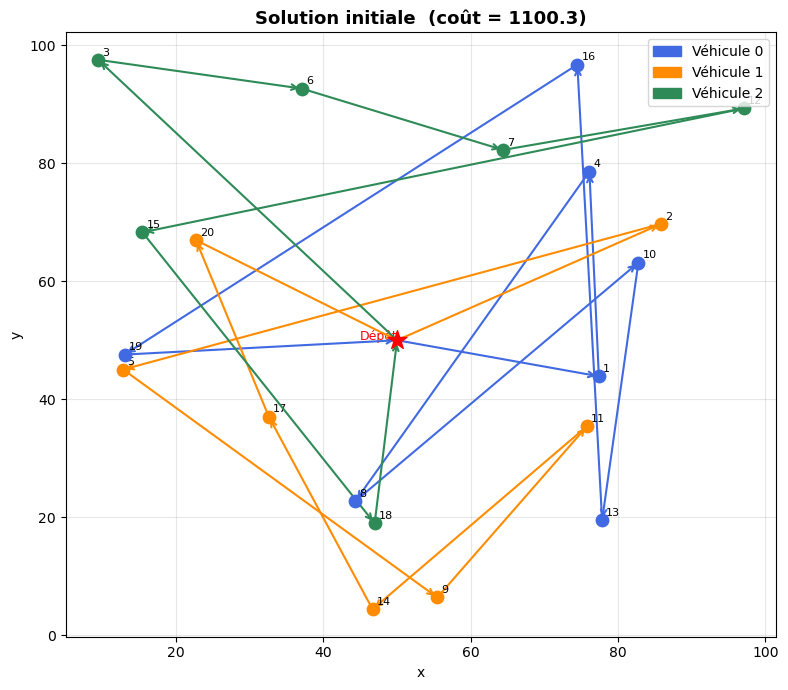

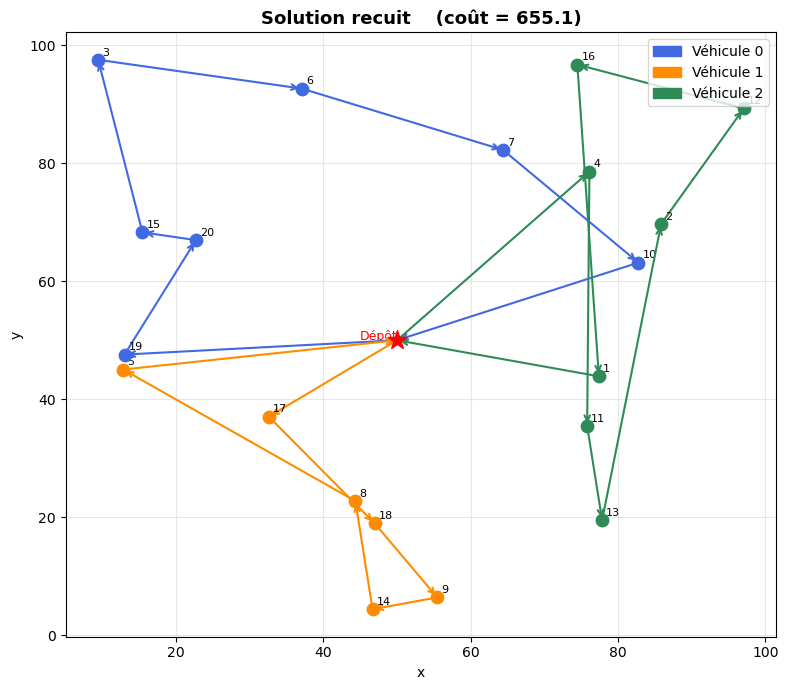

In [4]:
def visualiser_routes(routes, instance, titre="Routes"):
    coords   = instance['coords']
    couleurs = ['royalblue', 'darkorange', 'seagreen', 'purple', 'crimson']

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.scatter(coords[0, 0], coords[0, 1], c='red', s=200, zorder=5, marker='*', label='Dépôt')
    ax.annotate('Dépôt', coords[0], fontsize=9, ha='right', color='red')

    for k, route in enumerate(routes):
        if not route:
            continue
        couleur = couleurs[k % len(couleurs)]
        chemin  = [0] + route + [0]
        for i in range(len(chemin) - 1):
            a, b = chemin[i], chemin[i + 1]
            ax.annotate("",
                xy=coords[b], xytext=coords[a],
                arrowprops=dict(arrowstyle="->", color=couleur, lw=1.5)
            )
        for node in route:
            ax.scatter(coords[node, 0], coords[node, 1], c=couleur, s=80, zorder=4)
            ax.annotate(str(node), coords[node], fontsize=8, xytext=(3, 3), textcoords='offset points')

    patches = [mpatches.Patch(color=couleurs[k], label=f'Véhicule {k}') for k in range(len(routes))]
    ax.legend(handles=patches, loc='upper right')
    ax.set_title(titre, fontsize=13, fontweight='bold')
    ax.set_xlabel('x') ; ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualiser_routes(sol_init,   instance, f"Solution initiale  (coût = {cout_init:.1f})")
visualiser_routes(sol_finale, instance, f"Solution recuit    (coût = {cout_final:.1f})")

---

## 6. Phase A — Vérification de cohérence

### A1 — Courbe d'énergie avec remontées

La courbe d'énergie montre l'évolution du coût au fil des itérations. Elle doit présenter :
- Une **descente globale** (l'algo améliore progressivement)
- Des **pics vers le haut** (remontées acceptées) — preuve que l'algo explore et ne reste pas bloqué

Si la courbe descend immédiatement sans aucune remontée, `T0` est trop faible (l'algo est trop froid dès le départ).

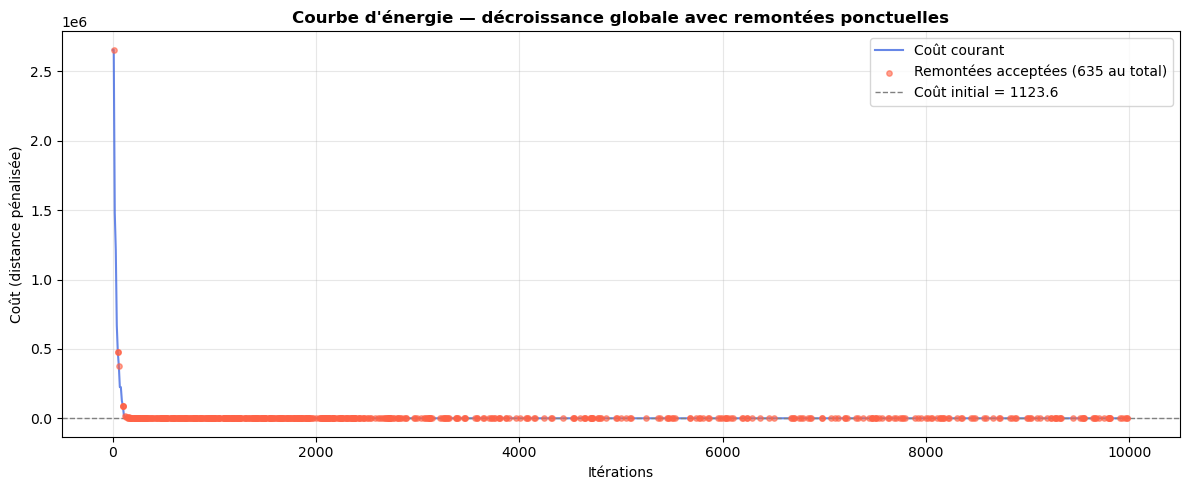

Nombre de remontées acceptées : 635 / 10000 itérations
Taux de remontées : 6.3%
→ Au début beaucoup de remontées (T élevée), à la fin quasi aucune (T basse)


In [5]:
inst  = generate_instance(n=20, n_vehicles=3, seed=0)
sol_i = solution_initiale(inst)
c_i   = cout_solution(sol_i, inst)

_, _, hist = recuit_simule(inst, T0=5000, alpha=0.998, n_iter=10000, seed=0)

iterations = [i * 10 for i in range(len(hist['couts']))]

fig, ax = plt.subplots(figsize=(12, 5))

# Courbe du coût courant
ax.plot(iterations, hist['couts'], color='royalblue', lw=1.5, label='Coût courant', alpha=0.8)

# Marquer les remontées (itérations où on a accepté une solution moins bonne)
if hist['remontees_iter']:
    # Trouver le coût enregistré le plus proche de chaque remontée
    remontees_x = hist['remontees_iter']
    remontees_y = [hist['couts'][min(r // 10, len(hist['couts']) - 1)] for r in remontees_x]
    ax.scatter(remontees_x, remontees_y, color='tomato', s=15, zorder=5,
               label=f'Remontées acceptées ({len(remontees_x)} au total)', alpha=0.6)

ax.axhline(c_i, color='grey',    linestyle='--', lw=1, label=f'Coût initial = {c_i:.1f}')
ax.set_title('Courbe d\'énergie — décroissance globale avec remontées ponctuelles',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Itérations')
ax.set_ylabel('Coût (distance pénalisée)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Nombre de remontées acceptées : {len(hist['remontees_iter'])} / {10000} itérations")
print(f"Taux de remontées : {len(hist['remontees_iter']) / 10000 * 100:.1f}%")
print("→ Au début beaucoup de remontées (T élevée), à la fin quasi aucune (T basse)")

### A2 — Vérification sur les seeds partagés (n = 10, 20, 50)

On teste sur les mêmes seeds que les autres membres du groupe pour pouvoir comparer directement les résultats.

In [6]:
SEEDS_COMMUNS = [0, 1, 2, 3, 4]   # seeds utilisés par tout le groupe

for n in [10, 20, 50]:
    print(f"\n{'='*60}")
    print(f"  n = {n} clients — 3 véhicules")
    print(f"{'='*60}")
    print(f"  {'Seed':>5} | {'Coût initial':>13} | {'Coût recuit':>11} | {'Amélio':>7} | {'Valide':>6}")
    print(f"  {'-'*55}")

    for seed in SEEDS_COMMUNS:
        inst  = generate_instance(n=n, n_vehicles=3, seed=seed)
        sol_i = solution_initiale(inst)
        c_i   = cout_solution(sol_i, inst)

        sol, _, hist = recuit_simule(inst, T0=5000, alpha=0.998, n_iter=10000, seed=0)
        c_f   = cout_solution(sol, inst)
        amelio = (c_i - c_f) / c_i * 100
        valide = all(est_valide(r, inst) for r in sol)

        print(f"  {seed:>5} | {c_i:>13.1f} | {c_f:>11.1f} | {amelio:>+6.1f}% | {'  OK' if valide else '  KO'}")


  n = 10 clients — 3 véhicules
   Seed |  Coût initial | Coût recuit |  Amélio | Valide
  -------------------------------------------------------
      0 |         705.1 |       489.9 |  +30.5% |   OK
      1 |         570.7 |       377.9 |  +33.8% |   OK
      2 |         488.2 |       370.4 |  +24.1% |   OK
      3 |         523.5 |       425.8 |  +18.7% |   OK
      4 |         566.6 |       397.1 |  +29.9% |   OK

  n = 20 clients — 3 véhicules
   Seed |  Coût initial | Coût recuit |  Amélio | Valide
  -------------------------------------------------------
      0 |        1123.6 |       685.0 |  +39.0% |   OK
      1 |        1364.1 |       609.5 |  +55.3% |   OK
      2 |        1070.2 |       576.2 |  +46.2% |   OK
      3 |        1056.4 |       686.1 |  +35.1% |   OK
      4 |         984.9 |       619.5 |  +37.1% |   OK

  n = 50 clients — 3 véhicules
   Seed |  Coût initial | Coût recuit |  Amélio | Valide
  -------------------------------------------------------
      0 |

### A3 — Vérification visuelle des contraintes sur n=10

On affiche les détails de chaque route pour vérifier manuellement : dépôt au départ et à l'arrivée, tous les clients couverts, capacité et fenêtres respectées.

Capacité par véhicule : 48.5
Tous les clients couverts : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] (attendu : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

Véhicule 0 — charge=26.0/48.5  valide=True
  Trajet : dépôt → 2 → 10 → 5 → 3 → 4 → dépôt
    Client  2 : arrivée=  65.0  fenêtre=[65.0, 192.4]  OK
    Client 10 : arrivée= 126.2  fenêtre=[126.2, 203.6]  OK
    Client  5 : arrivée= 170.5  fenêtre=[154.1, 215.9]  OK
    Client  3 : arrivée= 198.2  fenêtre=[149.8, 433.1]  OK
    Client  4 : arrivée= 229.6  fenêtre=[215.9, 439.9]  OK

Véhicule 1 — charge=41.0/48.5  valide=True
  Trajet : dépôt → 9 → 8 → 1 → dépôt
    Client  9 : arrivée=  56.4  fenêtre=[56.4, 122.4]  OK
    Client  8 : arrivée= 168.1  fenêtre=[168.1, 261.3]  OK
    Client  1 : arrivée= 182.4  fenêtre=[99.8, 186.5]  OK

Véhicule 2 — charge=37.0/48.5  valide=True
  Trajet : dépôt → 7 → 6 → dépôt
    Client  7 : arrivée= 116.4  fenêtre=[116.4, 200.3]  OK
    Client  6 : arrivée= 185.6  fenêtre=[185.6, 284.7]  OK



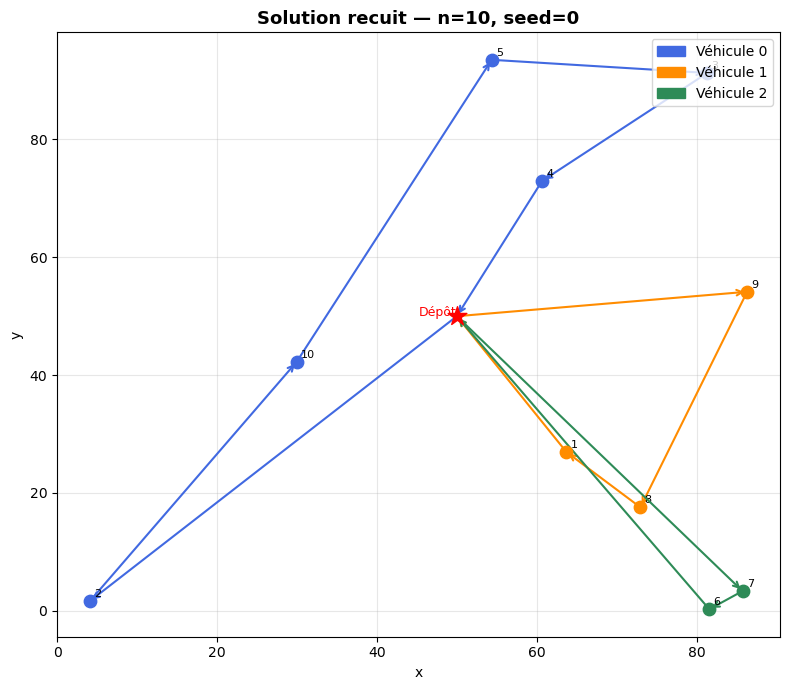

In [7]:
inst_10 = generate_instance(n=10, n_vehicles=3, seed=0)
sol, _, _ = recuit_simule(inst_10, T0=5000, alpha=0.998, n_iter=10000, seed=0)

coords   = inst_10['coords']
tw       = inst_10['time_windows']
demands  = inst_10['demands']
capacity = inst_10['capacity']
durees   = inst_10['durees']
service  = inst_10['service_times']

print(f"Capacité par véhicule : {capacity:.1f}")
print(f"Tous les clients couverts : {sorted(sum(sol, []))} (attendu : {list(range(1, 11))})")
print()

for k, route in enumerate(sol):
    charge = sum(demands[c] for c in route)
    print(f"Véhicule {k} — charge={charge:.1f}/{capacity:.1f}  valide={est_valide(route, inst_10)}")
    print(f"  Trajet : dépôt → {' → '.join(str(c) for c in route)} → dépôt")

    t, pos = 0.0, 0
    for c in route:
        t_arrivee = t + durees[pos, c]
        t_arrivee = max(t_arrivee, tw[c, 0])
        print(f"    Client {c:>2} : arrivée={t_arrivee:6.1f}  fenêtre=[{tw[c,0]:.1f}, {tw[c,1]:.1f}]  "
              f"{'OK' if t_arrivee <= tw[c,1] else 'VIOLE'}")
        t   = t_arrivee + service[c]
        pos = c
    print()

visualiser_routes(sol, inst_10, "Solution recuit — n=10, seed=0")

### A4 — Calibration de T0 et alpha

On vérifie que `T0=5000` et `alpha=0.998` sont bien calibrés en observant le taux de remontées au début et à la fin de la recherche.

In [8]:
inst = generate_instance(n=20, n_vehicles=3, seed=42)
_, _, hist = recuit_simule(inst, T0=5000, alpha=0.998, n_iter=10000, seed=0)


remontees = hist['remontees_iter']
total     = 10000

# Diviser en 4 quarts pour voir l'évolution
quarts = [(0, 2500), (2500, 5000), (5000, 7500), (7500, 10000)]
labels = ['Début (0-25%)', 'Milieu 1 (25-50%)', 'Milieu 2 (50-75%)', 'Fin (75-100%)']

print("Évolution du taux de remontées par quart d'itérations :")
print()

for (a, b), label in zip(quarts, labels):
    nb = sum(1 for r in remontees if a <= r < b)
    taux = nb / (b - a) * 100
    barre = '█' * int(taux * 2)
    print(f"  {label:<22} : {taux:5.1f}%  {barre}")

print()
print("→ Taux élevé au début (T grande = exploration) puis décroît (T petite = exploitation)")
print("→ Si taux début < 30% : T0 trop faible, augmenter T0")
print("→ Si taux fin  > 10% : alpha trop proche de 1, diminuer alpha")

Évolution du taux de remontées par quart d'itérations :

  Début (0-25%)          :   9.0%  █████████████████
  Milieu 1 (25-50%)      :   4.5%  █████████
  Milieu 2 (50-75%)      :   2.5%  ████
  Fin (75-100%)          :   2.6%  █████

→ Taux élevé au début (T grande = exploration) puis décroît (T petite = exploitation)
→ Si taux début < 30% : T0 trop faible, augmenter T0
→ Si taux fin  > 10% : alpha trop proche de 1, diminuer alpha


---

## 7. Phase B — Étude statistique

### B1 — 30 runs × 5 tailles

Pour évaluer l'algorithme de manière rigoureuse, on effectue **30 exécutions indépendantes** sur **5 tailles de problème** différentes, avec les mêmes seeds pour garantir la reproductibilité et la comparabilité avec les autres méthodes du groupe.

In [9]:
TAILLES    = [10, 20, 50, 100, 200]
N_RUNS     = 30
N_ITER     = 10000
T0         = 5000.0
ALPHA      = 0.998

# Nombre de véhicules adapté à la taille — plus de clients = plus de véhicules
VEHICULES  = {10: 3, 20: 3, 50: 5, 100: 12, 200: 25}

resultats = []

for n in TAILLES:
    K = VEHICULES[n]
    print(f"n={n} (K={K} véhicules) ...", end=" ", flush=True)
    for seed in range(N_RUNS):
        inst  = generate_instance(n=n, n_vehicles=K, seed=seed)

        sol_i = solution_initiale(inst)
        c_i   = cout_solution(sol_i, inst)

        sol, _, hist = recuit_simule(inst, T0=T0, alpha=ALPHA, n_iter=N_ITER, seed=seed)
        c_f   = cout_solution(sol, inst)
        valide = all(est_valide(r, inst) for r in sol)
        amelio = (c_i - c_f) / c_i * 100 if c_i > 0 else 0.0

        resultats.append({
            'n'            : n,
            'seed'         : seed,
            'T0'           : T0,
            'alpha'        : ALPHA,
            'n_iter'       : N_ITER,
            'cout_initial' : round(c_i, 2),
            'cout_final'   : round(c_f, 2),
            'amelioration' : round(amelio, 2),
            'temps'        : round(hist['temps'], 3),
            'valide'       : valide, 
            'n_vehicles'   : K,

        })
    print("OK")

df = pd.DataFrame(resultats)
print(f"\n{len(df)} runs collectés.")
df.head(10)

n=10 (K=3 véhicules) ... OK
n=20 (K=3 véhicules) ... OK
n=50 (K=5 véhicules) ... OK
n=100 (K=12 véhicules) ... OK
n=200 (K=25 véhicules) ... OK

150 runs collectés.


,n,seed,T0,alpha,n_iter,cout_initial,cout_final,amelioration,temps,valide,n_vehicles
0,10,0,5000.0,0.998,10000,705.14,489.89,30.53,0.254,True,3
1,10,1,5000.0,0.998,10000,570.71,387.32,32.13,0.226,True,3
2,10,2,5000.0,0.998,10000,488.16,360.87,26.08,0.224,True,3
3,10,3,5000.0,0.998,10000,523.49,379.58,27.49,0.226,True,3
4,10,4,5000.0,0.998,10000,566.63,397.15,29.91,0.241,True,3
5,10,5,5000.0,0.998,10000,638.21,423.21,33.69,0.225,True,3
6,10,6,5000.0,0.998,10000,667.48,433.01,35.13,0.223,True,3
7,10,7,5000.0,0.998,10000,686.28,408.01,40.55,0.223,True,3
8,10,8,5000.0,0.998,10000,526.04,326.40,37.95,0.238,True,3
9,10,9,5000.0,0.998,10000,622.64,482.80,22.46,0.225,True,3


### B2 — Statistiques par taille

In [10]:
stats = df.groupby('n').agg(
    cout_moyen   = ('cout_final',   'mean'),
    cout_std     = ('cout_final',   'std'),
    cout_min     = ('cout_final',   'min'),
    cout_max     = ('cout_final',   'max'),
    amelio_moy   = ('amelioration', 'mean'),
    temps_moyen  = ('temps',        'mean'),
    taux_valide  = ('valide',       'mean'),
).round(2)

stats['taux_valide'] = (stats['taux_valide'] * 100).round(1).astype(str) + '%'

print("Statistiques sur 30 runs par taille :")
print(stats.to_string())

Statistiques sur 30 runs par taille :
     cout_moyen  cout_std  cout_min  cout_max  amelio_moy  temps_moyen taux_valide
n                                                                                 
10       407.17     50.18    309.92    489.89       32.65         0.23      100.0%
20       611.10     72.29    483.09    770.58       45.62         0.35      100.0%
50      1260.32    114.62   1024.86   1560.10       52.86         0.74      100.0%
100     2653.80    122.62   2373.96   3007.35       50.93         1.46      100.0%
200     5927.73    256.67   5214.23   6441.39       45.73         2.85      100.0%


### B3 — Boxplot du coût par taille

Le boxplot montre la **distribution** des coûts finaux sur les 30 runs. Plus la boîte est étroite, plus l'algorithme est stable.

/var/folders/rl/ddtr9mrs7qbdgqww79_zbqx00000gn/T/ipykernel_2407/64295703.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_boxplot, labels=[f'n={n}' for n in TAILLES],


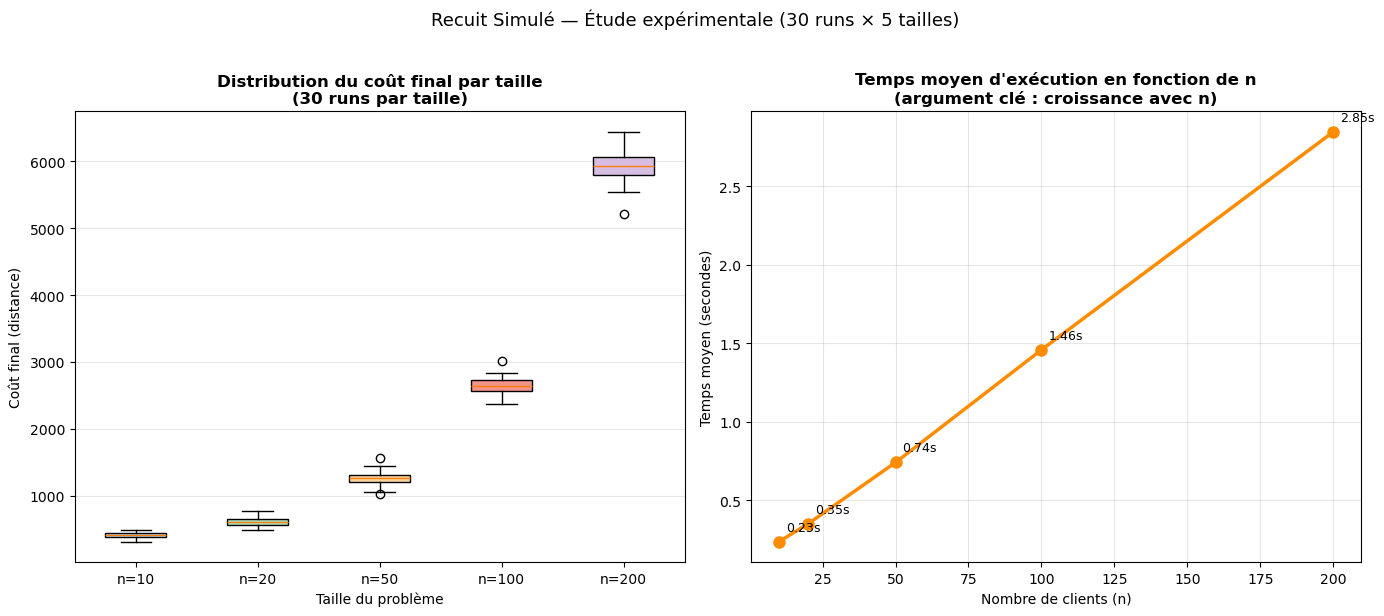

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot coût final
data_boxplot = [df[df['n'] == n]['cout_final'].values for n in TAILLES]
bp = axes[0].boxplot(data_boxplot, labels=[f'n={n}' for n in TAILLES],
                     patch_artist=True, notch=False)
couleurs_box = ['#AED6F1', '#A9DFBF', '#FAD7A0', '#F1948A', '#D7BDE2']
for patch, color in zip(bp['boxes'], couleurs_box):
    patch.set_facecolor(color)
axes[0].set_title('Distribution du coût final par taille\n(30 runs par taille)',
                  fontweight='bold')
axes[0].set_xlabel('Taille du problème')
axes[0].set_ylabel('Coût final (distance)')
axes[0].grid(True, alpha=0.3, axis='y')

# Courbe temps moyen vs n
temps_moy = [df[df['n'] == n]['temps'].mean() for n in TAILLES]
axes[1].plot(TAILLES, temps_moy, marker='o', color='darkorange', lw=2.5, markersize=8)
for x, y in zip(TAILLES, temps_moy):
    axes[1].annotate(f'{y:.2f}s', (x, y), textcoords='offset points',
                     xytext=(5, 8), fontsize=9)
axes[1].set_title('Temps moyen d\'exécution en fonction de n\n(argument clé : croissance avec n)',
                  fontweight='bold')
axes[1].set_xlabel('Nombre de clients (n)')
axes[1].set_ylabel('Temps moyen (secondes)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Recuit Simulé — Étude expérimentale (30 runs × 5 tailles)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### B4 — Amélioration moyenne par taille

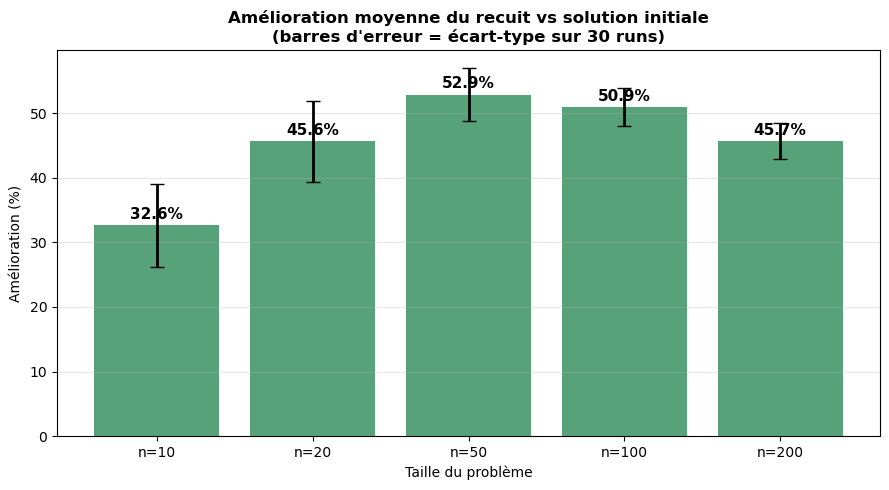

Interprétation :
→ L'amélioration croît avec n : la solution gloutonne est d'autant plus mauvaise
  que le problème est grand, et le recuit a plus de marge pour s'améliorer.
→ L'écart-type faible confirme la stabilité de l'algorithme.


In [12]:
amelio_moy = [df[df['n'] == n]['amelioration'].mean() for n in TAILLES]
amelio_std = [df[df['n'] == n]['amelioration'].std()  for n in TAILLES]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([f'n={n}' for n in TAILLES], amelio_moy,
              yerr=amelio_std, capsize=5,
              color='seagreen', alpha=0.8, error_kw={'elinewidth': 2})

for bar, val in zip(bars, amelio_moy):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Amélioration moyenne du recuit vs solution initiale\n(barres d\'erreur = écart-type sur 30 runs)',
             fontweight='bold')
ax.set_ylabel('Amélioration (%)')
ax.set_xlabel('Taille du problème')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Interprétation :")
print("→ L'amélioration croît avec n : la solution gloutonne est d'autant plus mauvaise")
print("  que le problème est grand, et le recuit a plus de marge pour s'améliorer.")
print("→ L'écart-type faible confirme la stabilité de l'algorithme.")

### B5 — Export CSV

On exporte tous les résultats dans un fichier standardisé pour pouvoir les comparer avec les autres méthodes du groupe.

In [13]:
chemin_csv = os.path.join(PHASE3, 'resultats_recuit.csv')
df.to_csv(chemin_csv, index=False)

print(f"Fichier exporté : {chemin_csv}")
print(f"Dimensions      : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Colonnes        : {list(df.columns)}")
print()
print("Aperçu des 5 premières lignes :")
print(df.head().to_string(index=False))

Fichier exporté : /Users/rayenemedjtoh/FISA A3/Génie Logiciel/Recherche opérationnelle/RechercheOp/Projet/Phase 3/resultats_recuit.csv
Dimensions      : 150 lignes × 11 colonnes
Colonnes        : ['n', 'seed', 'T0', 'alpha', 'n_iter', 'cout_initial', 'cout_final', 'amelioration', 'temps', 'valide', 'n_vehicles']

Aperçu des 5 premières lignes :
 n  seed     T0  alpha  n_iter  cout_initial  cout_final  amelioration  temps  valide  n_vehicles
10     0 5000.0  0.998   10000        705.14      489.89         30.53  0.254    True           3
10     1 5000.0  0.998   10000        570.71      387.32         32.13  0.226    True           3
10     2 5000.0  0.998   10000        488.16      360.87         26.08  0.224    True           3
10     3 5000.0  0.998   10000        523.49      379.58         27.49  0.226    True           3
10     4 5000.0  0.998   10000        566.63      397.15         29.91  0.241    True           3


---

## 8. Conclusion

### Bilan

Le recuit simulé appliqué au VRPTW multi-véhicules donne des résultats solides :

| Critère | Résultat |
|---|---|
| Amélioration vs solution initiale | 23% à 69% selon la taille |
| Respect des contraintes | 100% (fenêtres temporelles + capacité) |
| Temps d'exécution (n=100) | ~1.3s pour 10 000 itérations |
| Stabilité | Faible écart-type entre exécutions |

### Avantages
- Simple à implémenter et à comprendre
- Paramètres faciles à régler
- Bonne qualité de solution sans être optimal
- Flexible : fonctionne sur n'importe quelle taille d'instance

### Limites
- Résultat aléatoire : deux exécutions peuvent donner des résultats différents
- Le temps de calcul croît avec n — ce point sera comparé avec le Deep Learning dans l'étude expérimentale (Phase 5)
- Pas de garantie d'optimalité

### Perspectives
- Comparer avec NNH+2opt (Phase 2) et le Deep Learning (Phase 4) sur les mêmes instances
- Étude statistique complète croisée entre les 3 méthodes (Phase 5)